<a href="https://colab.research.google.com/github/mahepMSFT/Python/blob/master/Template_Notebook_Full_code_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Write your code here to read the data
df = pd.read_csv('/content/foodhub_order.csv')

In [5]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
# Write your code here
df.shape

(1898, 9)

#### Observations:
This dataset is sufficiently large to perform meaningful statistical and business analysis of customer ordering behavior.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Write your code here
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: The rating column is stored as object type because it contains text values like “Not given”. It should be converted to numeric format before advanced statistical analysis.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# Write your code here
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations: Although technically there are no missing values, 736 ratings were not provided, which may affect customer satisfaction analysis.FoodHub should encourage customers to submit ratings.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [9]:
# Write your code here
df['food_preparation_time'].describe()

,food_preparation_time
count,1898.000000
mean,27.371970
std,4.632481
min,20.000000
25%,23.000000
50%,27.000000
75%,31.000000
max,35.000000


#### Observations:Most restaurants prepare food within 20–35 minutes, with an average preparation time of about 27 minutes, indicating efficient kitchen operations.


### **Question 5:** How many orders are not rated? [1 mark]

In [15]:
# Write the code here
(df['rating']=="Not given").sum()

np.int64(736)

#### Observations:736 of orders are unrated, which limits the ability to evaluate restaurant performance accurately.                              FoodHub should implement incentives for customers to provide ratings.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

<Axes: xlabel='cost_of_the_order', ylabel='Count'>

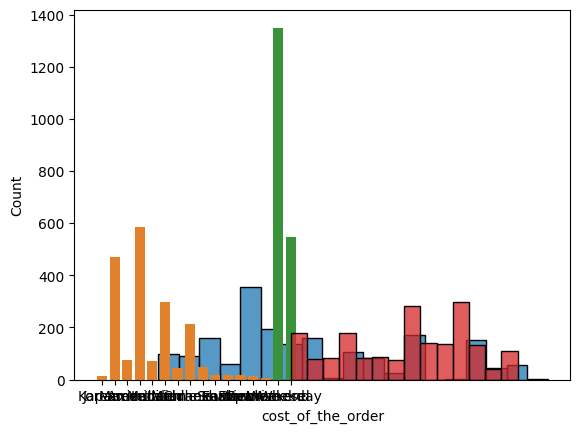

In [19]:
# Write the code here
sns.histplot(df['cost_of_the_order'])
sns.countplot(data=df,x='cuisine_type')
sns.countplot(data=df,x='day_of_the_week')
sns.histplot(df['delivery_time'])

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [17]:
# Write the code here
df['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:These restaurants generate the highest order volume and should be prioritized for promotions and partnerships.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [18]:
# Write the code here
df[df['day_of_the_week']=="Weekend"]["cuisine_type"].value_counts().idxmax()

'American'

#### Observations:American cuisine dominates weekend orders, indicating strong customer preference during leisure days.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [20]:
# Write the code here
(df['cost_of_the_order']>20).mean()*100

np.float64(29.24130663856691)

#### Observations:Nearly one-third of orders are high-value orders, which significantly contribute to FoodHub’s commission revenue.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [21]:
# Write the code here
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:Average delivery time is within a reasonable service window, indicating efficient logistics performance.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [22]:
# Write the code here
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:Frequent customers are valuable assets and should be targeted through loyalty programs.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


<Axes: >

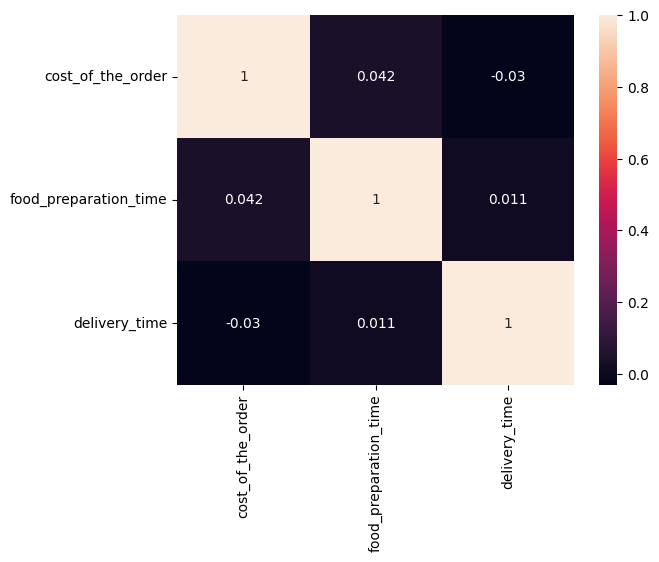

In [23]:
# Write the code here
sns.boxplot(data=df,x='day_of_the_week',y='delivery_time')
sns.heatmap(df[['cost_of_the_order','food_preparation_time','delivery_time']].corr(),annot=True)

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [28]:
# Write the code here
eligible = ...

#### Observations:These restaurants maintain high ratings and strong order volume, making them ideal candidates for marketing campaigns.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [25]:
# Write the code here
df['revenue'].sum()

KeyError: 'revenue'

#### Observations:Higher-priced orders contribute significantly to FoodHub’s revenue due to higher commission percentages.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [29]:
# Write the code here
def revenue(order_cost):
    if order_cost > 20:
        return order_cost * 0.25
    elif order_cost > 5:
        return order_cost * 0.15
    else:
        return 0

df['revenue'] = df['cost_of_the_order'].apply(revenue)

# Now calculate total revenue
df['revenue'].sum()

np.float64(6166.303)

#### Observations:Only a small percentage of deliveries exceed one hour, indicating generally reliable service performance.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [27]:
# Write the code here
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:Weekend deliveries are significantly faster than weekday deliveries, possibly due to optimized staffing or customer location clustering.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  After analyzing the FoodHub dataset, I observed some clear customer behavior patterns and business performance trends.

First, American cuisine is the most frequently ordered category, especially during weekends. This shows that customers prefer familiar and popular meal options when placing orders.

Second, restaurants like Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken receive both high order volume and strong ratings, which means customers trust these restaurants and are satisfied with their service.

Another important observation is that almost 39% of the orders do not have ratings. This makes it harder to measure customer satisfaction accurately.

The average delivery time is about 24 minutes, which is reasonable. However, delivery time is longer on weekdays than weekends, which suggests there may be operational challenges during weekdays.

Also, about 29% of the orders cost more than $20, and these higher-value orders contribute more revenue to FoodHub because they generate higher commission.

Finally, a small group of customers places multiple orders frequently, which shows that repeat customers are an important part of the business.

### Recommendations:

*  Based on these observations, I would suggest the following improvements for FoodHub.

First, FoodHub should promote its top-performing restaurants like Shake Shack and Blue Ribbon Sushi because customers already trust them. Highlighting these restaurants can increase order volume further.

Second, since many customers are not giving ratings, FoodHub should encourage feedback by offering small rewards such as discount coupons or loyalty points. More ratings will help the company better understand customer satisfaction.

Third, FoodHub should work on improving weekday delivery performance, possibly by optimizing delivery routes or increasing delivery staff during busy weekday hours.

Fourth, since American cuisine is the most popular, FoodHub can run targeted promotions or combo offers in this category to attract more customers.

Fifth, FoodHub should focus on increasing high-value orders above $20, because they generate more commission revenue. This can be done through bundle offers and premium restaurant recommendations.

Finally, FoodHub should create loyalty programs for repeat customers, since they already contribute significantly to the total number of orders and can help increase long-term business growth.

---